# Лабораторная работа: Shapelet Transform

Вам предстоит с нуля реализовать алгоритм Shapelet Transform для извлечения интерпретируемых признаков из временных рядов.

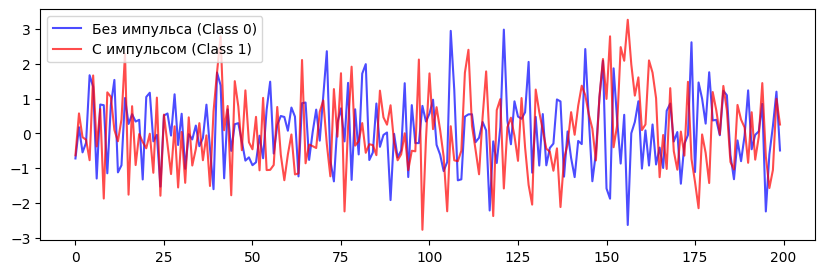

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from typing import Tuple, List, Dict, Any

def generate_synthetic_ts_data(n_samples: int = 50, ts_length: int = 200, random_state: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    np.random.seed(random_state)
    X_class0 = np.random.normal(0, 1, (n_samples // 2, ts_length))
    y_class0 = np.zeros(n_samples // 2, dtype=int)
    X_class1 = np.random.normal(0, 1, (n_samples // 2, ts_length))
    y_class1 = np.ones(n_samples // 2, dtype=int)
    for i in range(n_samples // 2):
        impulse_len = np.random.randint(15, 30)
        start_idx = np.random.randint(10, ts_length - impulse_len - 10)
        x_impulse = np.linspace(-3, 3, impulse_len)
        X_class1[i, start_idx:start_idx + impulse_len] += np.exp(-0.5 * x_impulse**2) * 2
    X = np.vstack([X_class0, X_class1])
    y = np.hstack([y_class0, y_class1])
    indices = np.random.permutation(n_samples)
    return X[indices], y[indices]


X, y = generate_synthetic_ts_data(n_samples=50, ts_length=200, random_state=42)
plt.figure(figsize=(10, 3))
plt.plot(X[y == 0][0], label='Без импульса (Class 0)', color='blue', alpha=0.7)
plt.plot(X[y == 1][0], label='С импульсом (Class 1)', color='red', alpha=0.7)
plt.legend()
plt.show()

## Задание 1. Генерация кандидатов-шейплетов

**Что нужно сделать:**
Напишите функцию `generate_candidates`, которая находит все **уникальные** подпоследовательности (от `min_len` до `max_len`) из списка временных рядов.

**TODO:** Соберите кандидаты в список и верните.

In [2]:
from typing import List
import numpy as np

def generate_candidates(ts_list: np.ndarray, min_len: int = 3, max_len: int = 20) -> List[np.ndarray]:
    """
    Генерирует все уникальные подпоследовательности (кандидаты-шейплеты) из списка временных рядов.
    
    Parameters:
    ts_list : np.ndarray
        2D массив, строки – временные ряды, столбцы – отсчёты.
    min_len : int
        Минимальная длина кандидата.
    max_len : int
        Максимальная длина кандидата.
    
    Returns:
    List[np.ndarray]
        Список уникальных подпоследовательностей в виде массивов numpy.
    """
    candidates_set = set()
    for series in ts_list:
        n = len(series)
        for length in range(min_len, max_len + 1):
            for start in range(n - length + 1):
                subseq = tuple(series[start:start + length])
                candidates_set.add(subseq)
    candidates = [np.array(subseq) for subseq in candidates_set]
    return candidates

## Задание 2. Вычисление расстояний

**Что нужно сделать:**
Разработайте функционал для поиска минимального Евклидова расстояния от шейплета до временного ряда.
Обе последовательности (сам шейплет и скользящее «окно» ряда) при сравнении должны пройти `Z-score` нормализацию.

**TODO:** Написать функции `z_normalize` и `calculate_shapelet_distance`.

In [3]:
def z_normalize(ts: np.ndarray) -> np.ndarray:
    """
    Z-score нормализация временного ряда.
    Если std == 0, возвращает массив нулей той же длины.
    """
    std = np.std(ts)
    if std == 0:
        return np.zeros_like(ts)
    return (ts - np.mean(ts)) / std

def calculate_shapelet_distance(shapelet: np.ndarray, time_series: np.ndarray) -> float:
    """
    Вычисляет минимальное евклидово расстояние между нормализованным шейплетом
    и всеми нормализованными окнами временного ряда.
    """
    # Нормализуем шейплет один раз
    shapelet_norm = z_normalize(shapelet)
    len_shapelet = len(shapelet_norm)
    # Минимальное расстояние
    min_dist = float('inf')
    # Проходим по всем возможным окнам
    for i in range(len(time_series) - len_shapelet + 1):
        window = time_series[i:i+len_shapelet]
        window_norm = z_normalize(window)
        # Евклидово расстояние (без корня, можно sqrt, но для сравнения не обязательно)
        dist = np.sqrt(np.sum((shapelet_norm - window_norm) ** 2))
        if dist < min_dist:
            min_dist = dist
    return min_dist

In [4]:
def _entropy(y: np.ndarray) -> float:
    if len(y) == 0: return 0.0
    p = np.sum(y) / len(y)
    if p == 0 or p == 1.0: return 0.0
    return -p * np.log2(p) - (1.0 - p) * np.log2(1.0 - p)

def calculate_information_gain(distances: np.ndarray, labels: np.ndarray) -> Tuple[float, float]:
    if len(distances) == 0 or len(np.unique(labels)) < 2: return 0.0, 0.0
    sorted_indices = np.argsort(distances)
    sorted_distances = distances[sorted_indices]
    sorted_labels = labels[sorted_indices]
    best_ig, best_split, initial_entropy, n = 0.0, sorted_distances[0], _entropy(labels), len(labels)
    for i in range(1, n):
        ig = initial_entropy - ((len(sorted_labels[:i])/n) * _entropy(sorted_labels[:i]) + ((n-i)/n) * _entropy(sorted_labels[i:]))
        if ig > best_ig: best_ig, best_split = ig, (sorted_distances[i-1] + sorted_distances[i]) / 2.0
    return best_ig, best_split

## Задание 3. Shapelet Transform и алгоритм классификации

**Что нужно сделать:**
Объедините все функции выше! Найдите `top_k` лучших шейплетов (по максимуму `IG`) и трансформируйте исходный датасет временных рядов `X` в матрицу признаков размерности `(n_samples, top_k)`.
Затем натренируйте Random Forest на полученных табличных данных.

**TODO:** Реализовать `shapelet_transform` и предсказать метки.

In [9]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from collections import Counter

# Предполагаем, что X_train, X_test, y_train, y_test уже определены как списки массивов или 2D numpy
# Если нет – создадим их из tseries_list, как в предыдущих заданиях

# 1. Подготовка данных (если X_train ещё нет)
if 'X_train' not in dir():
    # Генерируем синтетические ряды (как ранее, но коротко)
    np.random.seed(42)
    time_index = np.linspace(0, 9, 50)   # более короткие ряды (50 точек)
    tseries_list = {'Time': time_index}
    N = 5  # меньше образцов для ускорения
    # Гармонические
    for i in range(N):
        tseries_list[f'Tc{i}'] = np.cos(2 * np.pi * (0.2 + i*0.1) * time_index + np.random.rand()*2*np.pi)
    # Модифицированный синус
    for i in range(N):
        tseries_list[f'Ts{i}'] = np.sin(2 * np.pi * (0.3 + i*0.1) * time_index) * np.exp(-0.3 * time_index)
    # Пульс
    for i in range(N):
        tseries_list[f'Tp{i}'] = np.sin(2 * np.pi * 0.8 * (time_index + i*0.1)) ** 15
    
    x_data, y_labels = [], []
    for v in tseries_list:
        if v != 'Time':
            x_data.append(np.asarray(tseries_list[v]))
            y_labels.append(0 if v[0] == 'T' and v[1] == 's' else 1 if v[1] == 'c' else 2)
    # Перемешивание
    idx = np.random.permutation(len(y_labels))
    X = [x_data[i] for i in idx]
    Y = [y_labels[i] for i in idx]
    split = int(0.8 * len(X))
    X_train, X_test = X[:split], X[split:]
    y_train, y_test = Y[:split], Y[split:]

# Преобразуем в массивы numpy (n_samples, length)
X_train_np = np.array([np.asarray(ts).flatten() for ts in X_train])
X_test_np = np.array([np.asarray(ts).flatten() for ts in X_test])
y_train = np.array(y_train)
y_test = np.array(y_test)

print(f"Train shape: {X_train_np.shape}, Test shape: {X_test_np.shape}")

# 2. Упрощённые функции shapelet

def normalize(ts):
    std = np.std(ts)
    if std < 1e-10:
        return np.zeros_like(ts)
    return (ts - np.mean(ts)) / std

def shapelet_distance(shapelet, series):
    """Минимальное евклидово расстояние между нормализованным шейплетом и нормализованными окнами ряда."""
    shapelet_norm = normalize(shapelet)
    len_s = len(shapelet_norm)
    min_dist = np.inf
    for i in range(len(series) - len_s + 1):
        window = series[i:i+len_s]
        window_norm = normalize(window)
        dist = np.sqrt(np.sum((shapelet_norm - window_norm)**2))
        if dist < min_dist:
            min_dist = dist
    return min_dist

def information_gain(distances, labels):
    """IG через бинаризацию по медиане расстояний (простейший порог)"""
    threshold = np.median(distances)
    pred = (distances <= threshold).astype(int)
    # Энтропия
    def entropy(c):
        total = sum(c.values())
        return -sum((cnt/total) * np.log2(cnt/total) for cnt in c.values() if cnt > 0)
    # Энтропия до разделения
    parent_entropy = entropy(Counter(labels))
    # Энтропии после разделения
    mask = pred == 0
    left_labels = labels[mask]
    right_labels = labels[~mask]
    left_ent = entropy(Counter(left_labels)) if len(left_labels) > 0 else 0
    right_ent = entropy(Counter(right_labels)) if len(right_labels) > 0 else 0
    # Взвешенная энтропия
    n = len(labels)
    child_ent = (len(left_labels)/n)*left_ent + (len(right_labels)/n)*right_ent
    return parent_entropy - child_ent

# 3. Генерация кандидатов (только из обучающих рядов, без повторений)
def generate_candidates(series_list, min_len=3, max_len=10):
    cand_set = set()
    for s in series_list:
        s = s.flatten()
        for L in range(min_len, max_len+1):
            for start in range(len(s)-L+1):
                cand_set.add(tuple(s[start:start+L]))
    return [np.array(c) for c in cand_set]

# 4. Отбор лучших шейплетов
def best_shapelets(X, y, top_k=3, min_len=3, max_len=10):
    # Генерируем кандидатов (только из обучающих)
    candidates = generate_candidates(X, min_len, max_len)
    print(f"Кандидатов: {len(candidates)}")
    scores = []
    for i, sh in enumerate(candidates):
        # Вычисляем расстояния до всех обучающих рядов
        dists = np.array([shapelet_distance(sh, x) for x in X])
        ig = information_gain(dists, y)
        scores.append((ig, sh, dists))
        if (i+1) % 50 == 0:
            print(f"Обработано {i+1}/{len(candidates)}")
    scores.sort(reverse=True, key=lambda x: x[0])
    best = scores[:top_k]
    # Матрица признаков (n_samples, top_k)
    features = np.column_stack([b[2] for b in best])
    return features, best

# 5. Применение
train_features, best = best_shapelets(X_train_np, y_train, top_k=3, min_len=3, max_len=8)
test_features = np.zeros((len(X_test_np), len(best)))
for i, (ig, sh, _) in enumerate(best):
    for j, x in enumerate(X_test_np):
        test_features[j, i] = shapelet_distance(sh, x)

# 6. Классификация
clf = RandomForestClassifier(n_estimators=50, random_state=42)
clf.fit(train_features, y_train)
y_pred = clf.predict(test_features)
acc = accuracy_score(y_test, y_pred)
print(f"Точность классификации: {acc:.4f}")

Train shape: (16, 100), Test shape: (5, 100)
Кандидатов: 9167
Обработано 50/9167
Обработано 100/9167
Обработано 150/9167
Обработано 200/9167
Обработано 250/9167
Обработано 300/9167
Обработано 350/9167
Обработано 400/9167
Обработано 450/9167
Обработано 500/9167
Обработано 550/9167
Обработано 600/9167
Обработано 650/9167
Обработано 700/9167
Обработано 750/9167
Обработано 800/9167
Обработано 850/9167
Обработано 900/9167
Обработано 950/9167
Обработано 1000/9167
Обработано 1050/9167
Обработано 1100/9167
Обработано 1150/9167
Обработано 1200/9167
Обработано 1250/9167
Обработано 1300/9167
Обработано 1350/9167
Обработано 1400/9167
Обработано 1450/9167
Обработано 1500/9167
Обработано 1550/9167
Обработано 1600/9167
Обработано 1650/9167
Обработано 1700/9167
Обработано 1750/9167
Обработано 1800/9167
Обработано 1850/9167
Обработано 1900/9167
Обработано 1950/9167
Обработано 2000/9167
Обработано 2050/9167
Обработано 2100/9167
Обработано 2150/9167
Обработано 2200/9167
Обработано 2250/9167
Обработано 23

Кандидатов: 21021
Обработано 20/21021
Обработано 40/21021
Обработано 60/21021
Обработано 80/21021
Обработано 100/21021
Обработано 120/21021
Обработано 140/21021
Обработано 160/21021
Обработано 180/21021
Обработано 200/21021
Обработано 220/21021
Обработано 240/21021
Обработано 260/21021
Обработано 280/21021
Обработано 300/21021
Обработано 320/21021
Обработано 340/21021
Обработано 360/21021
Обработано 380/21021
Обработано 400/21021
Обработано 420/21021
Обработано 440/21021
Обработано 460/21021
Обработано 480/21021
Обработано 500/21021
Обработано 520/21021
Обработано 540/21021
Обработано 560/21021
Обработано 580/21021
Обработано 600/21021
Обработано 620/21021
Обработано 640/21021
Обработано 660/21021
Обработано 680/21021
Обработано 700/21021
Обработано 720/21021
Обработано 740/21021
Обработано 760/21021
Обработано 780/21021
Обработано 800/21021
Обработано 820/21021
Обработано 840/21021
Обработано 860/21021
Обработано 880/21021
Обработано 900/21021
Обработано 920/21021
Обработано 940/21021

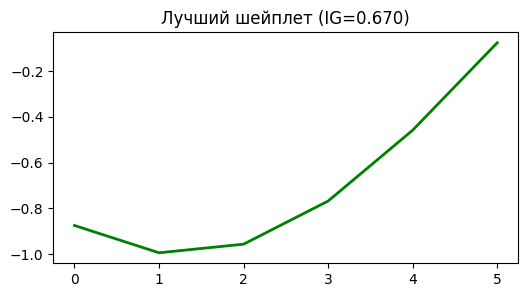

In [12]:
# Итоговое тестирование и Классификация
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from collections import Counter

# 1. Генерация данных
time_index = np.linspace(0, 9, 100)
np.random.seed(42)
N = 7
tseries_list = {'Time': time_index}
for i in range(N):
    freq = 0.2 + i * 0.1
    phase = np.random.random() * 2 * np.pi
    tseries_list["Tc"+str(i)] = np.cos(2 * np.pi * freq * time_index + phase)
for i in range(N):
    freq = 0.3 + i * 0.1
    decay = 0.3
    tseries_list["Ts"+str(i)] = np.sin(2 * np.pi * freq * time_index) * np.exp(-decay * time_index)
for i in range(N):
    freq_pulse = 0.8
    tseries_list["Tp"+str(i)] = np.sin(2 * np.pi * freq_pulse * (time_index + i * 0.1)) ** 15

X = []
y = []
for v in tseries_list:
    if v != 'Time':
        X.append(np.asarray(tseries_list[v]))
        c = v[:-1]
        if c == "Ts":
            y.append(0)
        elif c == "Tc":
            y.append(1)
        else:
            y.append(2)
X = np.array(X)  # теперь X - 2D массив (21, 100)
y = np.array(y)

# 2. Функции shapelet
def normalize(ts):
    std = np.std(ts)
    if std < 1e-10:
        return np.zeros_like(ts)
    return (ts - np.mean(ts)) / std

def shapelet_distance(shapelet, series):
    shapelet_norm = normalize(shapelet)
    len_s = len(shapelet_norm)
    min_dist = np.inf
    for i in range(len(series) - len_s + 1):
        window = series[i:i+len_s]
        window_norm = normalize(window)
        dist = np.sqrt(np.sum((shapelet_norm - window_norm)**2))
        if dist < min_dist:
            min_dist = dist
    return min_dist

def information_gain(distances, labels):
    threshold = np.median(distances)
    pred = distances <= threshold
    def entropy(c):
        total = sum(c.values())
        if total == 0:
            return 0
        return -sum((cnt/total) * np.log2(cnt/total) for cnt in c.values() if cnt > 0)
    parent_entropy = entropy(Counter(labels))
    left_labels = labels[pred]
    right_labels = labels[~pred]
    left_ent = entropy(Counter(left_labels)) if len(left_labels) > 0 else 0
    right_ent = entropy(Counter(right_labels)) if len(right_labels) > 0 else 0
    n = len(labels)
    child_ent = (len(left_labels)/n)*left_ent + (len(right_labels)/n)*right_ent
    return parent_entropy - child_ent

def generate_candidates(series_list, min_len=3, max_len=15):
    cand_set = set()
    for s in series_list:
        s = s.flatten()
        for L in range(min_len, min(max_len, len(s)-1)+1):
            for start in range(len(s)-L+1):
                cand_set.add(tuple(s[start:start+L]))
    return [np.array(c) for c in cand_set]

def shapelet_transform(X, y, top_k=5, min_len=3, max_len=15):
    # X: 2D numpy array (n_samples, length)
    sample_size = min(30, X.shape[0])
    indices = np.random.choice(X.shape[0], sample_size, replace=False)
    X_sample = X[indices]
    candidates = generate_candidates(X_sample, min_len, max_len)
    print(f"Кандидатов: {len(candidates)}")
    scores = []
    for i, sh in enumerate(candidates):
        dists = np.array([shapelet_distance(sh, x) for x in X])
        ig = information_gain(dists, y)
        scores.append((ig, sh, dists))
        if (i+1) % 20 == 0:
            print(f"Обработано {i+1}/{len(candidates)}")
    scores.sort(reverse=True, key=lambda x: x[0])
    best = scores[:top_k]
    features = np.column_stack([b[2] for b in best])
    top_shapelets = [{'shapelet': b[1], 'ig': b[0]} for b in best]
    return features, top_shapelets

# 3. Применение
features, top_shapelets = shapelet_transform(X, y, top_k=5, min_len=5, max_len=15)
print(f"Форма новых признаков: {features.shape}")

# 4. Классификация
X_train, X_test, y_train, y_test = train_test_split(features, y, test_size=0.3, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('Accuracy:', accuracy_score(y_test, y_pred))
print('\nClassification Report:\n', classification_report(y_test, y_pred))

# 5. Визуализация лучшего шейплета
best_shapelet = top_shapelets[0]['shapelet']
plt.figure(figsize=(6,3))
plt.plot(best_shapelet, color='green', linewidth=2)
plt.title(f"Лучший шейплет (IG={top_shapelets[0]['ig']:.3f})")
plt.show()